In [ ]:
# Import xlsx file LT Spare Parts Forecasting.xlsx - import numpy pandas, time series related llibraries

!pip install openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler

# Load the Excel file
file_path = 'LT Spare Parts Forecasting.xlsx'
try:
    df = pd.read_excel(file_path)
    print("File loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

# Display the first few rows and info
if 'df' in locals():
    print("\nDataFrame Info:")
    df.info()
    print("\nFirst 5 rows:")
    print(df.head())

File loaded successfully.

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Month            49 non-null     datetime64[ns]
 1   205-70-N1190     49 non-null     int64         
 2   PC_198_27_42263  48 non-null     float64       
 3   PC_203_32_51461  48 non-null     float64       
 4   PC_600_863_4210  48 non-null     float64       
 5   PC_6735_61_3410  48 non-null     float64       
 6   D30141135        49 non-null     int64         
 7   600-181-6740I.   49 non-null     int64         
 8   07063-51210I.    49 non-null     int64         
 9   600-319-4540I.   49 non-null     int64         
 10  6735-51-5143I    49 non-null     int64         
 11  07000-B2011I.    49 non-null     int64         
dtypes: datetime64[ns](1), float64(4), int64(7)
memory usage: 4.7 KB

First 5 rows:
       Month  205-70-N1190  

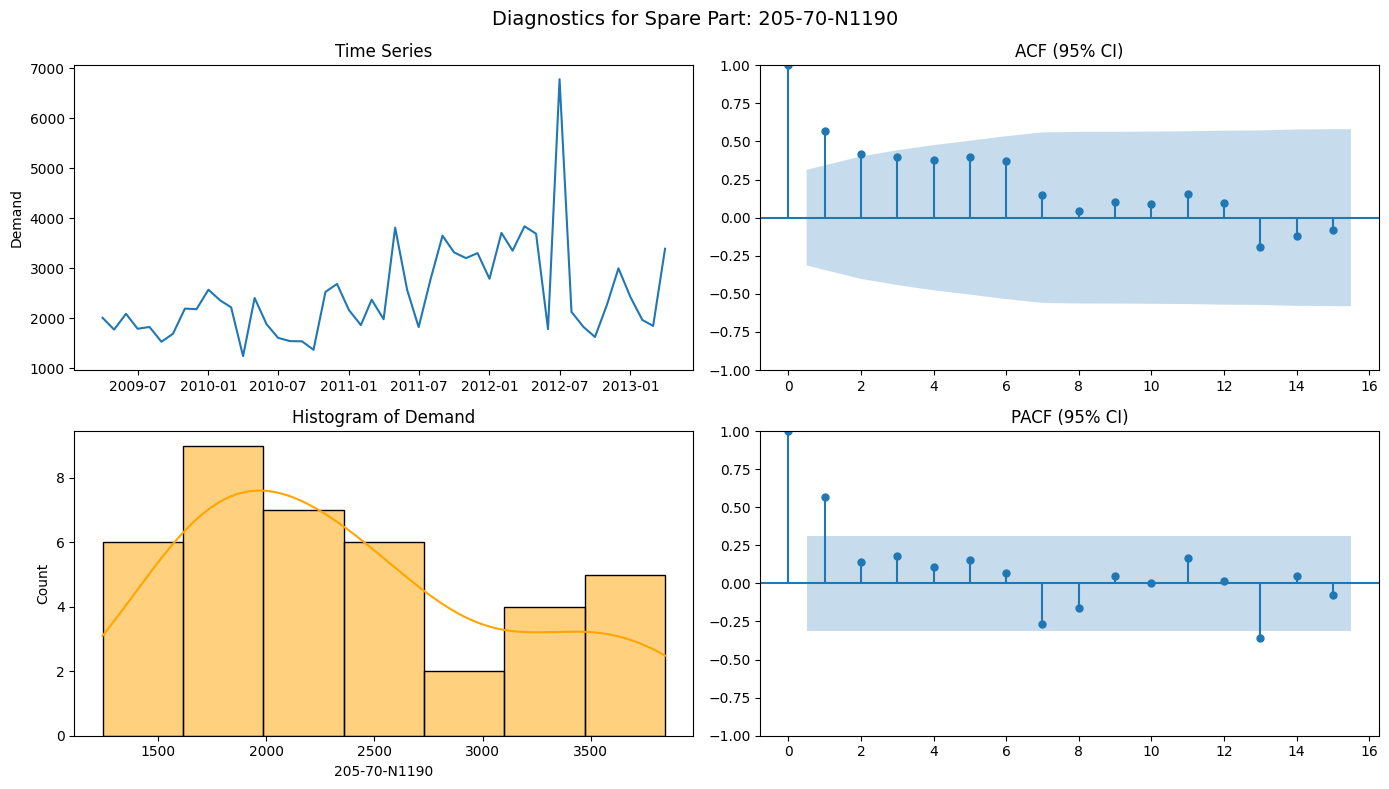

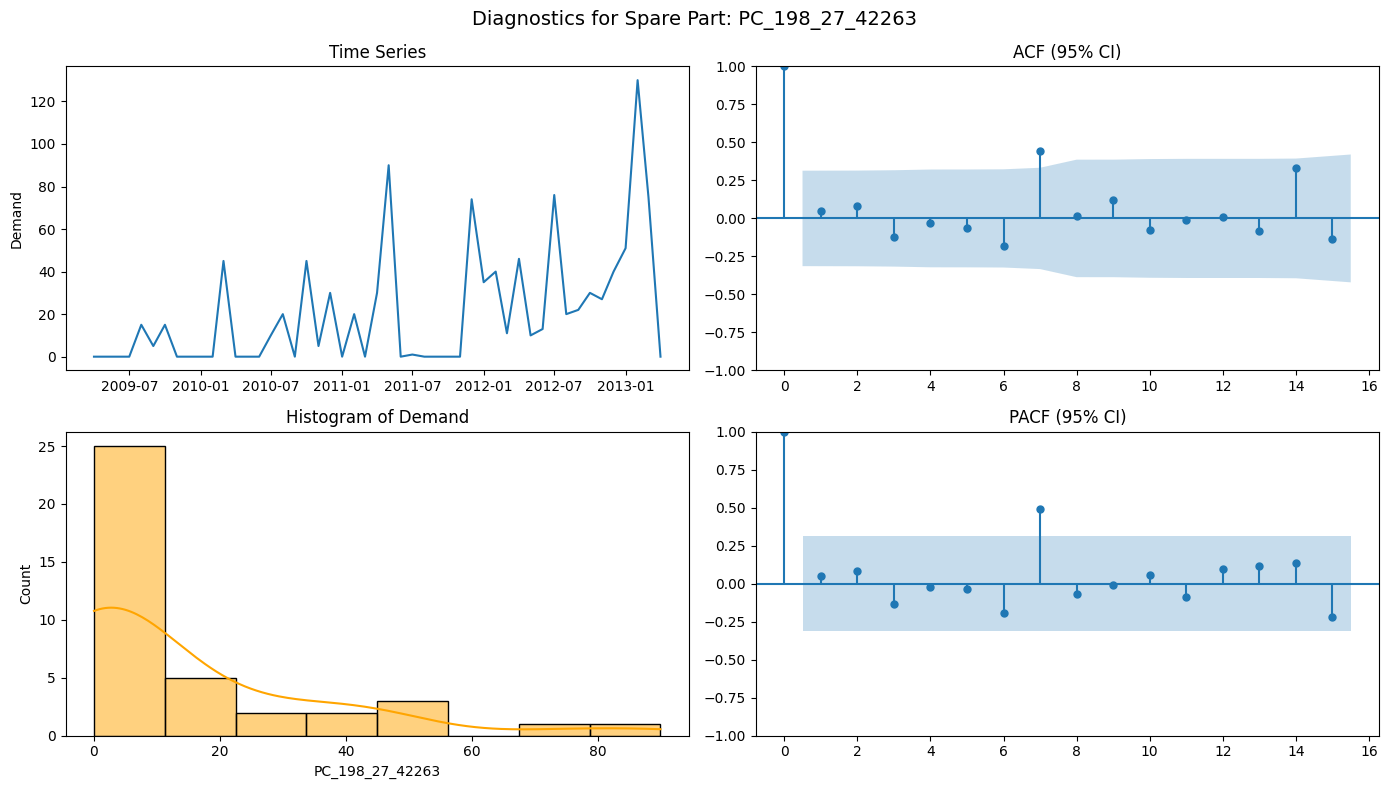

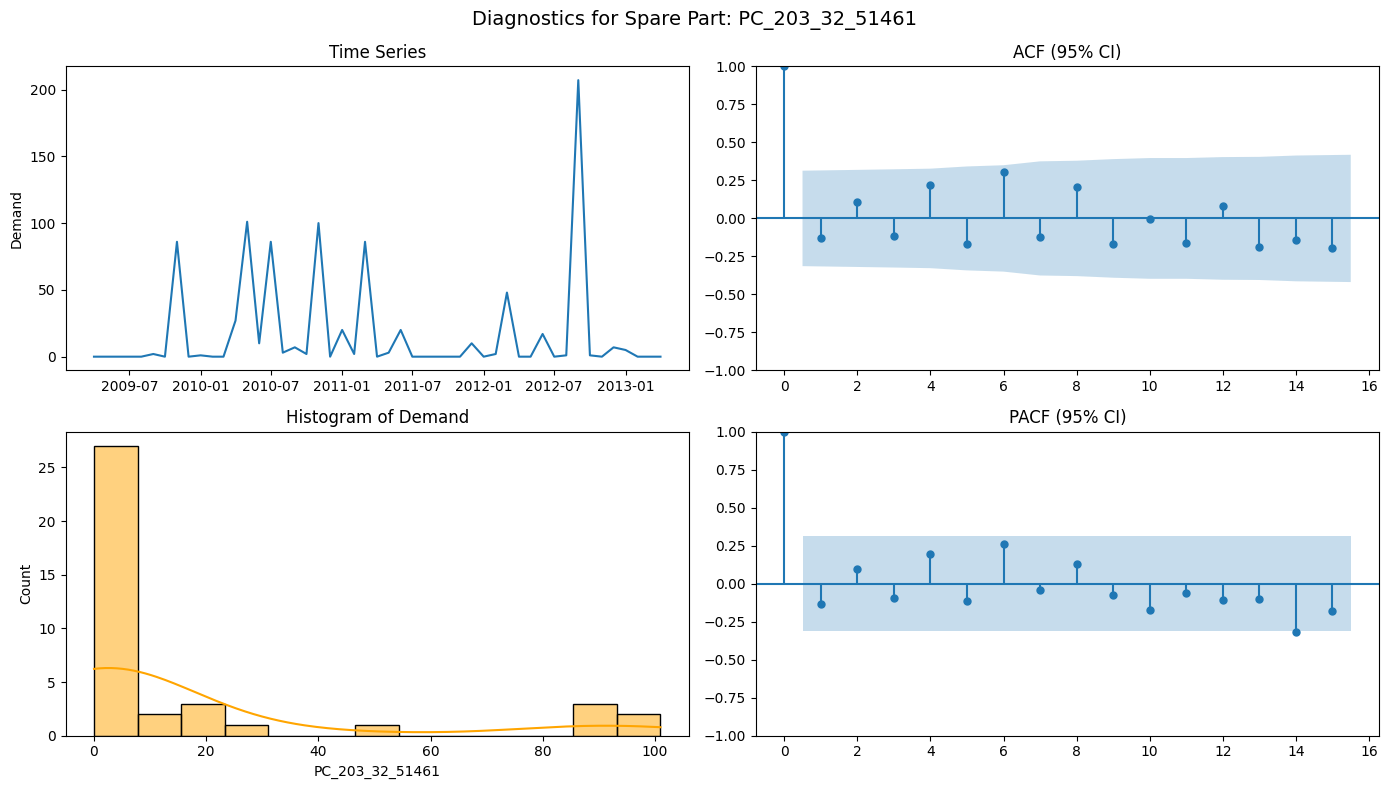

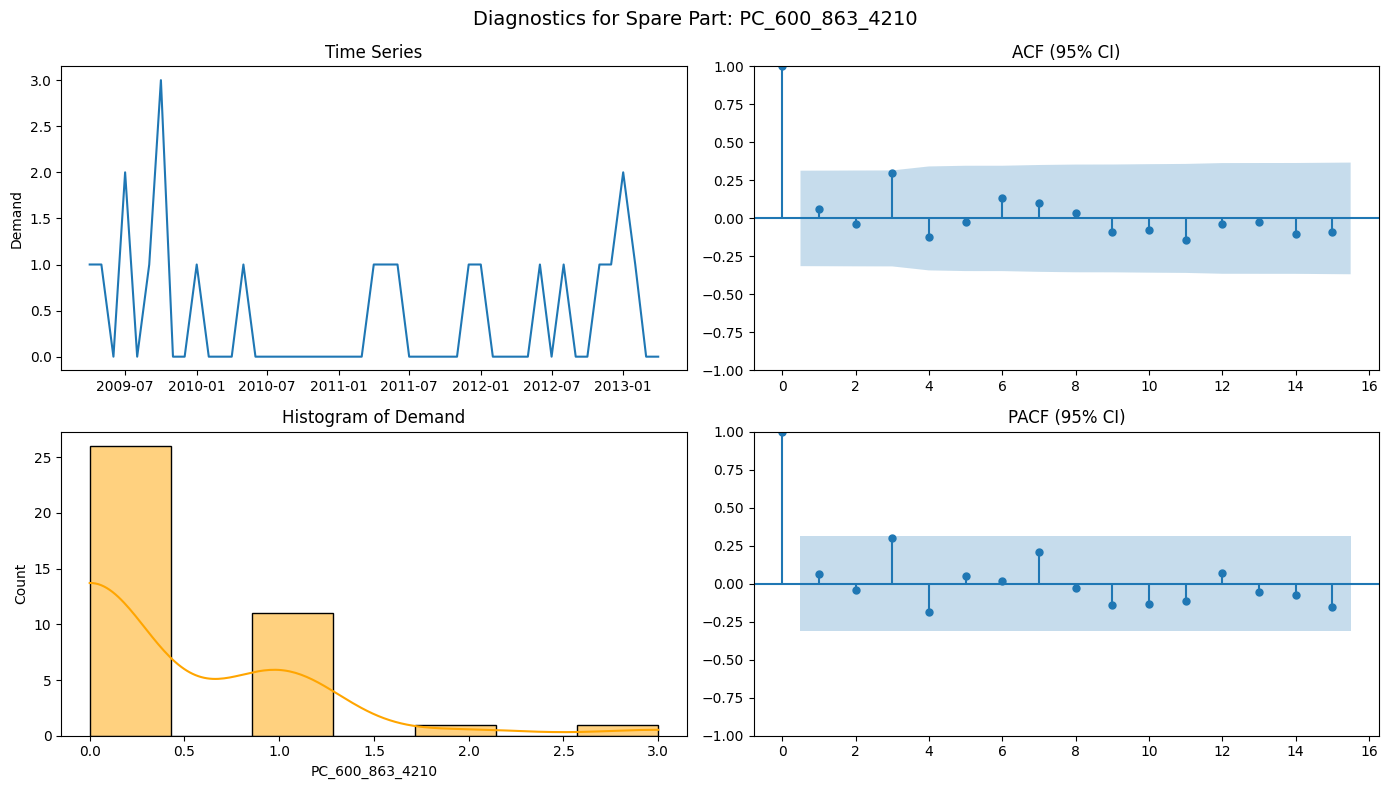

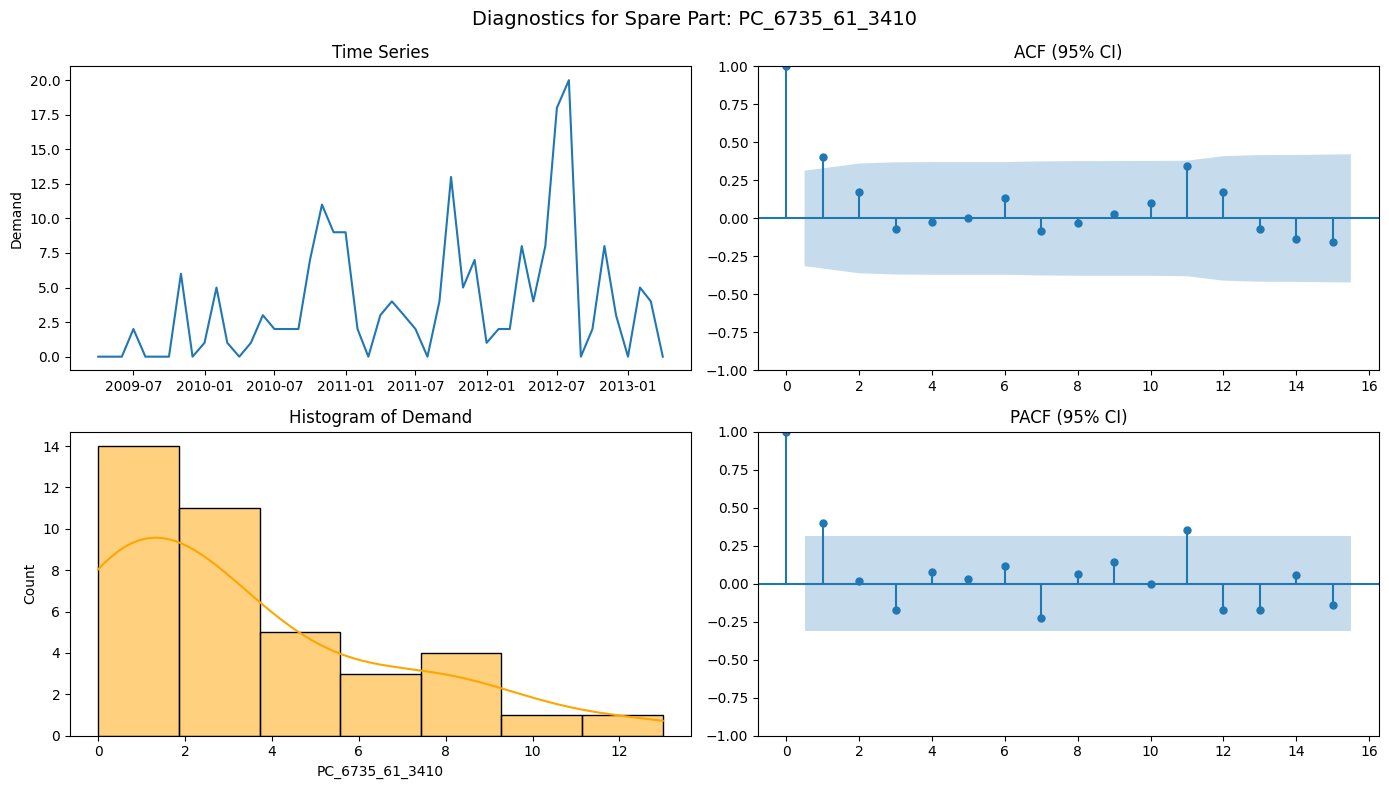

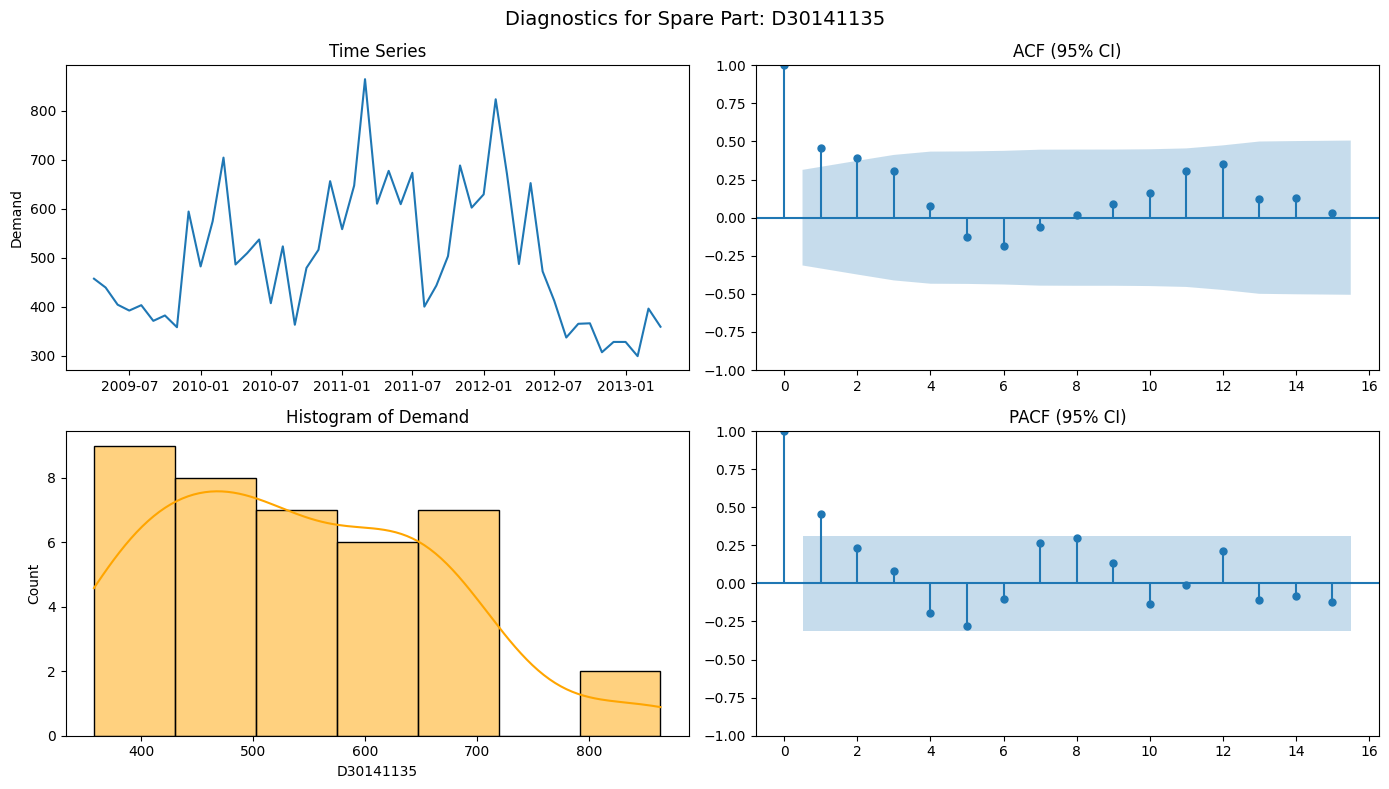

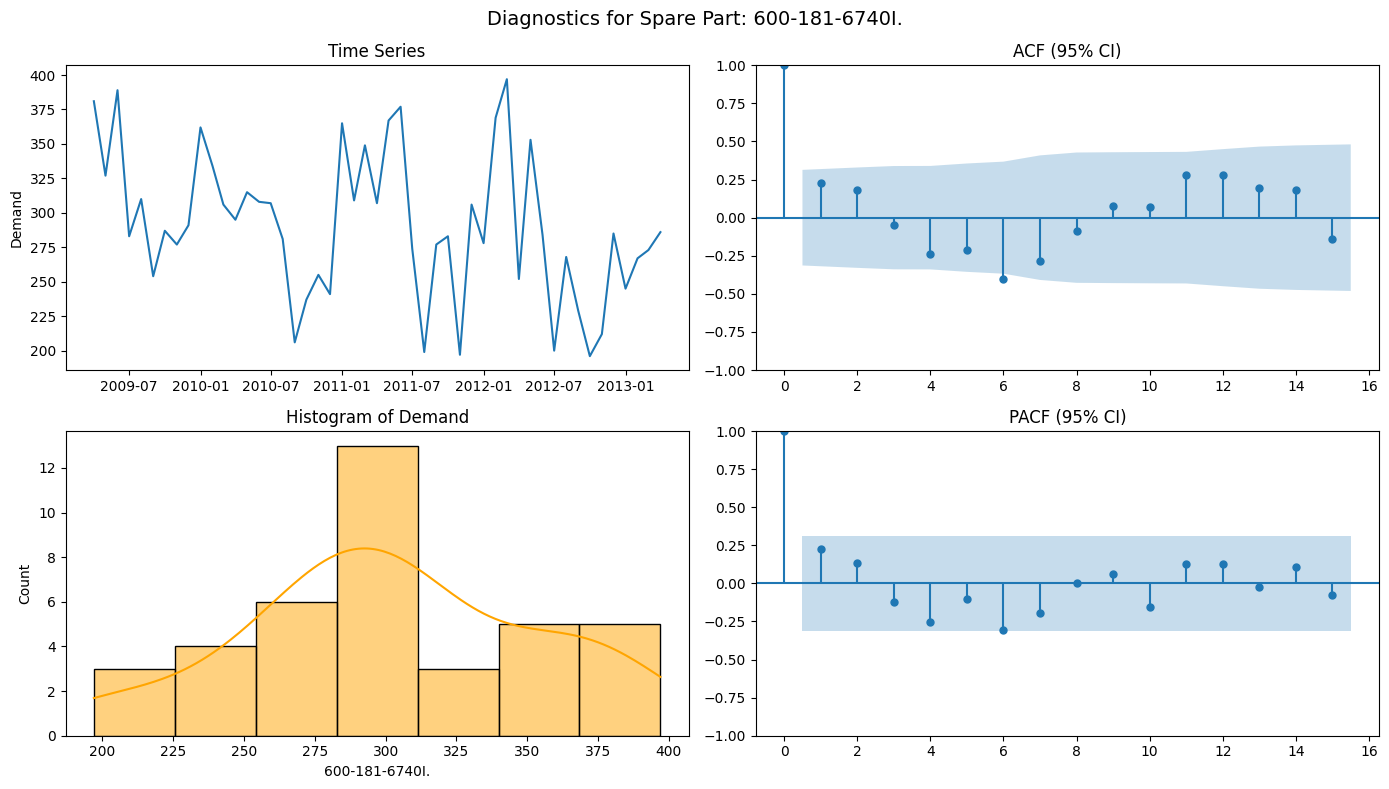

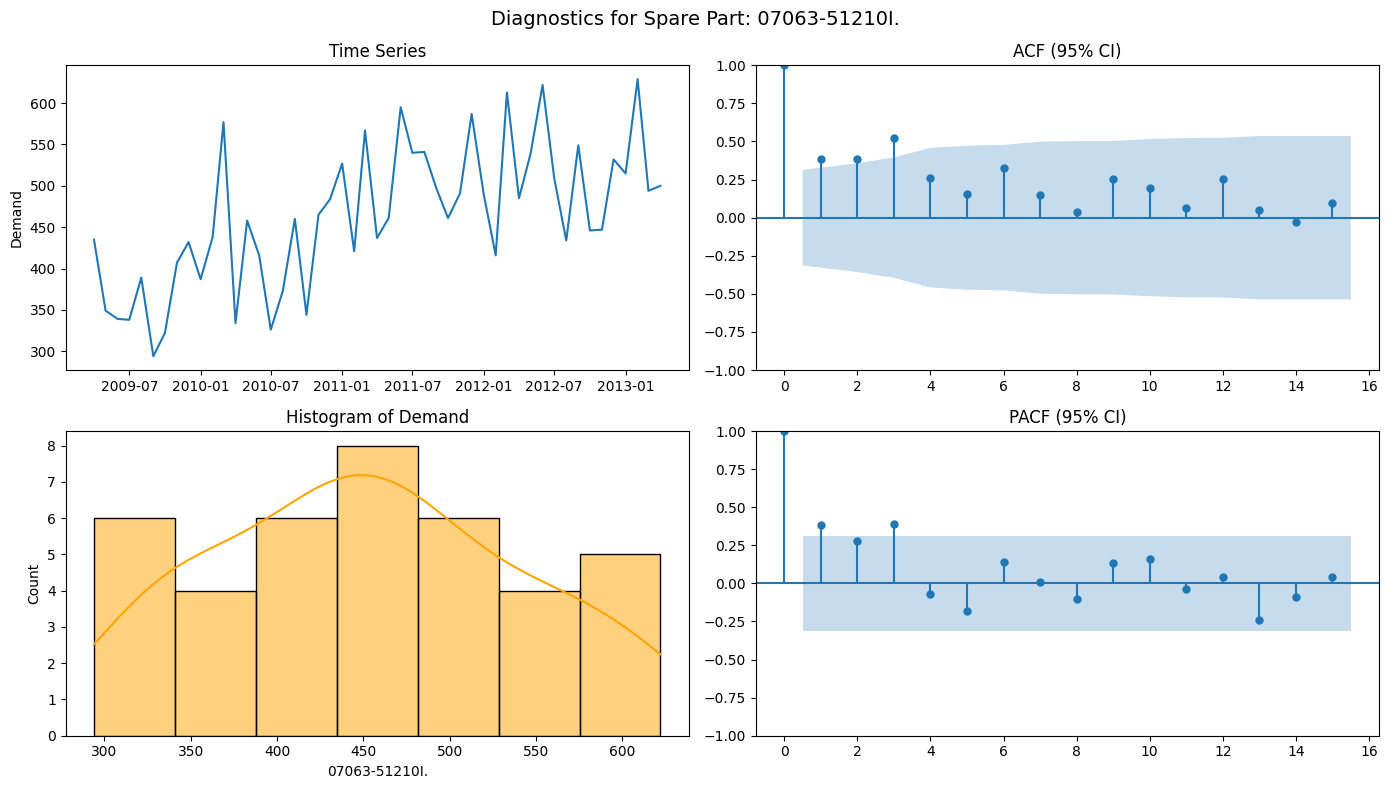

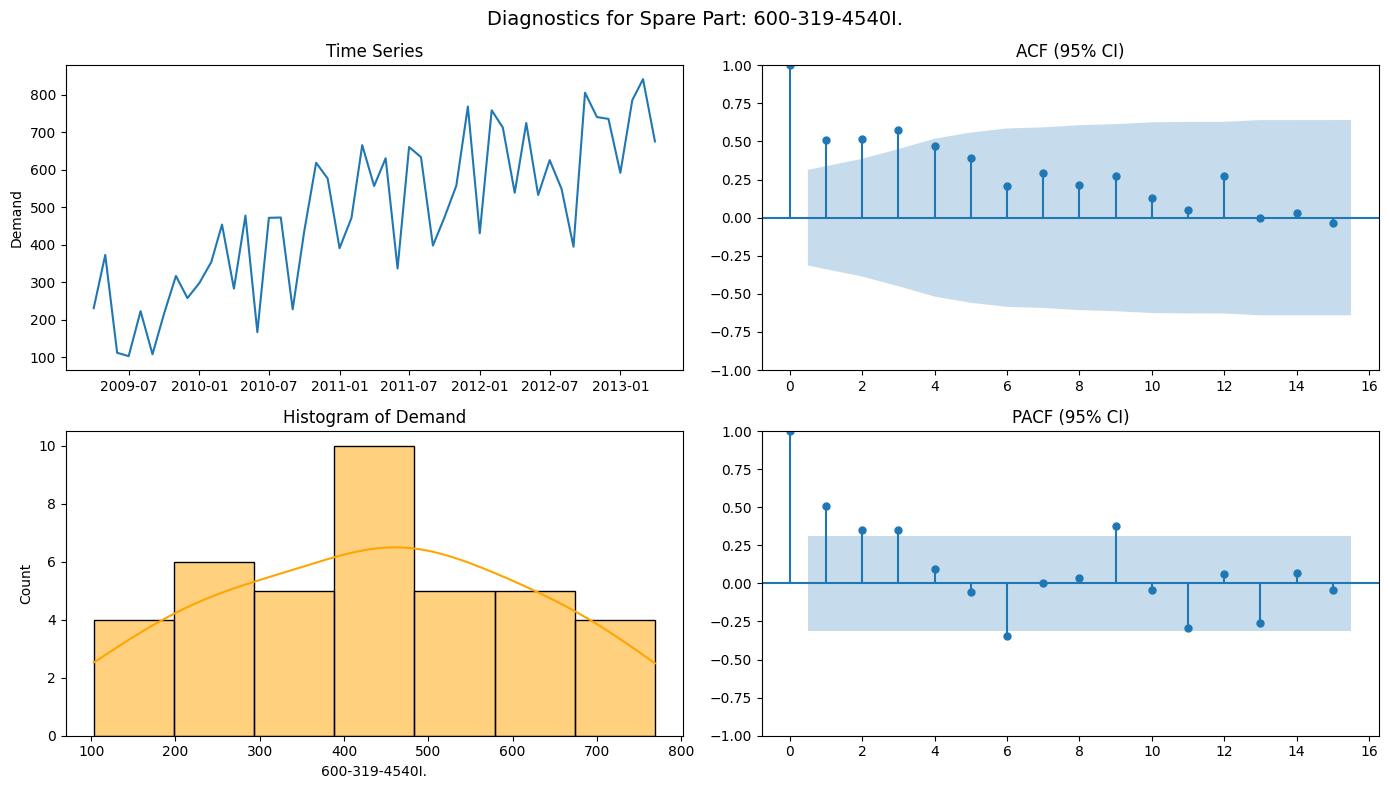

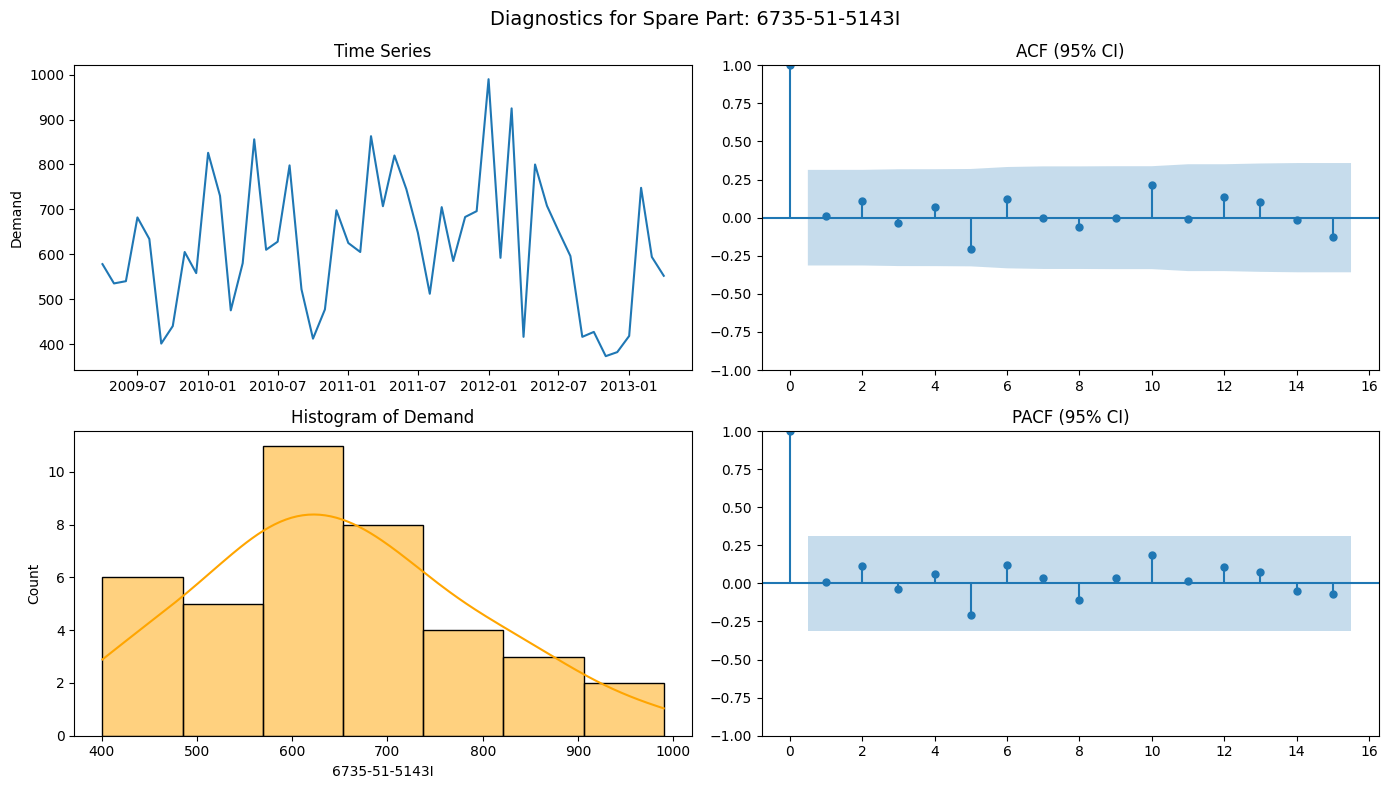

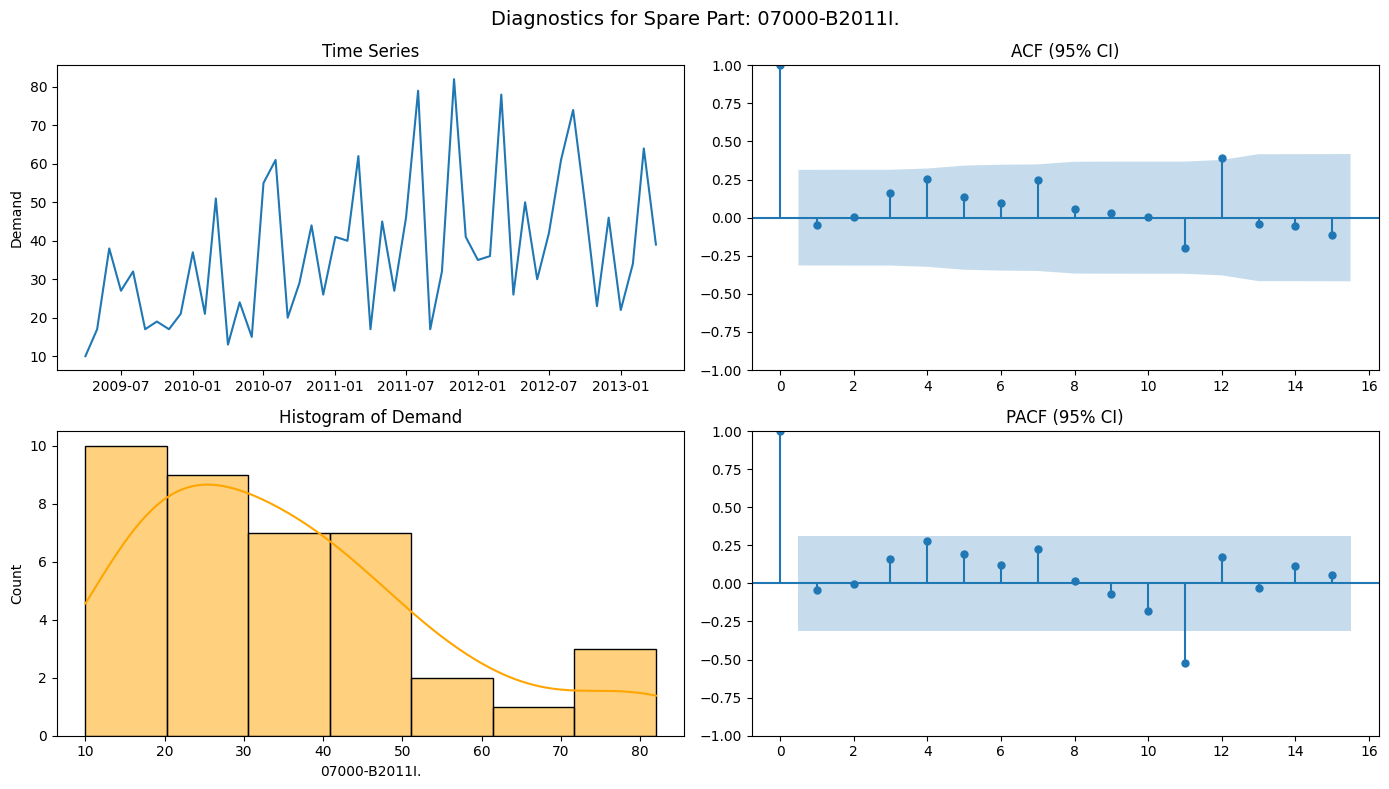


Stationarity Summary:

               Part  ADF p-value      ADF Result
0      205-70-N1190       0.0276      Stationary
1   PC_198_27_42263       0.8803  Non-Stationary
2   PC_203_32_51461       0.0000      Stationary
3   PC_600_863_4210       0.0000      Stationary
4   PC_6735_61_3410       0.0034      Stationary
5         D30141135       0.4285  Non-Stationary
6    600-181-6740I.       0.0009      Stationary
7     07063-51210I.       0.7335  Non-Stationary
8    600-319-4540I.       0.5454  Non-Stationary
9     6735-51-5143I       0.0000      Stationary
10    07000-B2011I.       0.1211  Non-Stationary


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Load the Excel file
file_path = "LT Spare Parts Forecasting.xlsx"  # Adjust this path if needed
df = pd.read_excel(file_path, sheet_name="Data")

# Preprocessing
df["Month"] = pd.to_datetime(df["Month"])
df.set_index("Month", inplace=True)
spare_parts = df.columns

# Split into train/test
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

# Store results
diagnostics = []

for part in spare_parts:
    train = train_df[part].fillna(0)
    full_series = df[part].fillna(0)

    # ADF Test
    adf_stat, p_value, _, _, _, _ = adfuller(train)
    adf_result = "Stationary" if p_value < 0.05 else "Non-Stationary"

    # Plotting
    fig, axs = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f"Diagnostics for Spare Part: {part}", fontsize=14)

    # Time Series
    axs[0, 0].plot(full_series)
    axs[0, 0].set_title("Time Series")
    axs[0, 0].set_ylabel("Demand")

    # Histogram
    sns.histplot(train, kde=True, ax=axs[1, 0], color="orange")
    axs[1, 0].set_title("Histogram of Demand")

    # ACF with confidence interval
    plot_acf(train, ax=axs[0, 1], lags=min(15, len(train)//2 - 1), alpha=0.05)
    axs[0, 1].set_title("ACF (95% CI)")

    # PACF with confidence interval
    plot_pacf(train, ax=axs[1, 1], lags=min(15, len(train)//2 - 1), alpha=0.05, method="ywmle")
    axs[1, 1].set_title("PACF (95% CI)")

    plt.tight_layout()
    plt.show()

    # Store ADF results
    diagnostics.append({
        "Part": part,
        "ADF p-value": round(p_value, 4),
        "ADF Result": adf_result
    })

# Show final summary table
diagnostics_df = pd.DataFrame(diagnostics)
print("\nStationarity Summary:\n")
print(diagnostics_df)


In [ ]:
# Re-import necessary libraries
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

# # Reload the Excel file
# file_path = "/mnt/data/LT Spare Parts Forecasting.xlsx"
# df = pd.read_excel(file_path, sheet_name="Data")

# # Preprocessing
# df["Month"] = pd.to_datetime(df["Month"])
# df.set_index("Month", inplace=True)
# spare_parts = df.columns

# # Split into train/test
# split_idx = int(len(df) * 0.8)
# train_df = df.iloc[:split_idx]
# test_df = df.iloc[split_idx:]

# Define custom Croston implementation
def croston_forecast(ts, alpha=0.1, n_forecast=1):
    ts = np.array(ts)
    n = len(ts)
    q, a, p = [], [], []
    last_demand, last_period = 0, 1
    for i in range(n):
        if ts[i] > 0:
            q.append(ts[i])
            a.append(last_period)
            last_period = 1
        else:
            last_period += 1
    if len(q) < 2:
        return np.zeros(n_forecast)
    z = q[0]
    p = a[0]
    for i in range(1, len(q)):
        z = alpha * q[i] + (1 - alpha) * z
        p = alpha * a[i] + (1 - alpha) * p
    forecast = z / p
    return np.array([forecast] * n_forecast)

# Store evaluation results
evaluation_results = []

for part in spare_parts:
    series = df[part].fillna(0)
    train = train_df[part].fillna(0)
    test = test_df[part].fillna(0)
    horizon = len(test)

    part_result = {"Part": part}

    # Default forecasts as NaNs
    forecasts = {
        "SES": np.full(horizon, np.nan),
        "Holt": np.full(horizon, np.nan),
        "Holt-Winters": np.full(horizon, np.nan),
        "ARIMA": np.full(horizon, np.nan),
        "Croston": np.full(horizon, np.nan),
    }

    # 1. Simple Exponential Smoothing
    try:
        model = SimpleExpSmoothing(train).fit()
        forecasts["SES"] = model.forecast(horizon)
    except:
        pass

    # 2. Holt's Linear Trend
    try:
        model = Holt(train).fit()
        forecasts["Holt"] = model.forecast(horizon)
    except:
        pass

    # 3. Holt-Winters (Additive)
    try:
        model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12).fit()
        forecasts["Holt-Winters"] = model.forecast(horizon)
    except:
        pass

    # 4. ARIMA (basic config)
    try:
        model = ARIMA(train, order=(1,1,0)).fit()
        forecasts["ARIMA"] = model.forecast(horizon)
    except:
        pass

    # 5. Croston
    try:
        forecasts["Croston"] = croston_forecast(train.values, n_forecast=horizon)
    except:
        pass

    # Calculate MAPE for each
    for model_name, forecast in forecasts.items():
        try:
            mape = mean_absolute_percentage_error(test, forecast)
        except:
            mape = np.nan
        part_result[f"{model_name}_MAPE"] = round(mape, 4) if not np.isnan(mape) else None

    evaluation_results.append(part_result)

# Convert to DataFrame
eval_df = pd.DataFrame(evaluation_results)

eval_df


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

,Part,SES_MAPE,Holt_MAPE,Holt-Winters_MAPE,ARIMA_MAPE,Croston_MAPE
0,205-70-N1190,4.281000e-01,3.775000e-01,5.028000e-01,2.340000e-01,3.925000e-01
1,PC_198_27_42263,9.361388e+15,1.481171e+16,1.688604e+16,5.399501e+15,6.019491e+15
2,PC_203_32_51461,2.705163e+16,2.705158e+16,5.854964e+16,2.211232e+16,2.236458e+16
3,PC_600_863_4210,7.631595e+14,7.368199e+14,6.379384e+14,1.496961e+15,9.265796e+14
4,PC_6735_61_3410,6.953277e+15,7.967223e+15,8.580756e+15,9.566037e+15,5.183469e+15
5,D30141135,6.153000e-01,4.778000e-01,4.453000e-01,5.265000e-01,6.922000e-01
6,600-181-6740I.,2.796000e-01,2.463000e-01,1.532000e-01,2.709000e-01,2.587000e-01
7,07063-51210I.,1.190000e-01,4.230000e-01,1.735000e-01,1.975000e-01,8.230000e-02
8,600-319-4540I.,1.899000e-01,1.965000e-01,1.508000e-01,1.906000e-01,2.190000e-01
9,6735-51-5143I,4.234000e-01,4.968000e-01,4.701000e-01,5.209000e-01,4.270000e-01
